# SHAP Analsysis 

In [1]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colorbar as cbar
from collections import Counter
import warnings
warnings.simplefilter("ignore")


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
path_invariant = 'Invariant Speeds Young and Older Correct\SHAP_analysis.xlsx'
path_variant = 'Variant Speeds Young and Older\SHAP_analysis.xlsx'

In [3]:
invariant_EXCEL = pd.ExcelFile(path_invariant)
variant_EXCEL = pd.ExcelFile(path_variant)

In [4]:
models_invariant = {}
SHAP_invariant_models= {}

for model in invariant_EXCEL.sheet_names:
    models_invariant[model] = pd.read_excel(invariant_EXCEL, sheet_name=model)
    print("Model load: ", model)
    # Count occurrences
    feature_counts = models_invariant[model]['Most Contributing Feat'].value_counts()
    # Get the most frequent feature
    most_frequent_feature = feature_counts.idxmax()
    most_frequent_count = feature_counts.max()  
    # Cols to a list 
    cols = list(models_invariant[model].columns)
    first_feature = cols[4]
    last_feature = cols[-3]
    features_model = cols[cols.index(first_feature):cols.index(last_feature)]
    # Features from the model
    if len(features_model) <= 5:
        SHAP_feats = features_model
        SHAP_invariant_models[model] = models_invariant[model]
        SHAP_invariant_young = models_invariant[model][models_invariant[model]['Group'] == 0]
        SHAP_invariant_older = models_invariant[model][models_invariant[model]['Group'] == 1]
        SHAP_values = models_invariant[model].loc[:, SHAP_feats]
        SHAP_average_MCF = SHAP_values[features_model].mean()
        SHAP_average_MCF_old = SHAP_invariant_older[features_model].mean()
        SHAP_average_MCF_young =SHAP_invariant_young[features_model].mean()
        print("Most contribuing feature: ", most_frequent_feature)
        print("Cunting of this feature: ", most_frequent_count)
        #print("SHAP_value: ", SHAP_average_MCF)
        print("SHAP_value Older: \n", SHAP_average_MCF_old)
        print("SHAP_value Young: \n", SHAP_average_MCF_young)

Model load:  Sheet1_138106
Most contribuing feature:  Sha_Foot_Angle_X_HS
Cunting of this feature:  107
SHAP_value Older: 
 Pelv_Angle_Y_MIN_SW_time    0.431231
Pelv_Angle_X_OHS            0.401919
Sha_Foot_Angle_X_HS         0.554808
Pelv_Angle_Y_ROM            0.534255
Trunk_Angle_X_OTO           0.493679
dtype: float64
SHAP_value Young: 
 Pelv_Angle_Y_MIN_SW_time    0.325801
Pelv_Angle_X_OHS            0.271092
Sha_Foot_Angle_X_HS         0.432172
Pelv_Angle_Y_ROM            0.440156
Trunk_Angle_X_OTO           0.393032
dtype: float64
Model load:  Sheet1_42680


In [5]:
file_name = 'Invariant Speeds Young and Older Correct\SHAP_top5_models_invariant.xlsx'
# Save all sheets to a new Excel file
with pd.ExcelWriter(file_name) as writer:
    for sheet_name, df_SHAP in SHAP_invariant_models.items():
        df_SHAP.to_excel(writer, sheet_name=sheet_name, index=False)

In [6]:
SHAP_feats

['Pelv_Angle_Y_MIN_SW_time',
 'Pelv_Angle_X_OHS',
 'Sha_Foot_Angle_X_HS',
 'Pelv_Angle_Y_ROM',
 'Trunk_Angle_X_OTO']

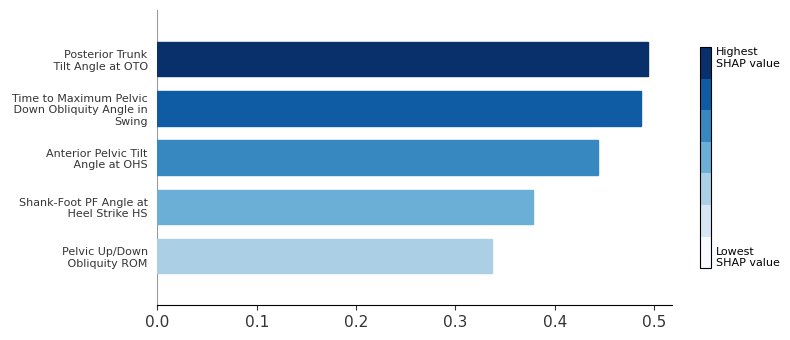

In [ ]:
#New features names for plot
features = ["Shank-Foot PF Angle at\n Heel Strike HS", "Pelvic Up/Down\n Obliquity ROM", "Posterior Trunk\n Tilt Angle at OTO", "Time to Maximum Pelvic\n Down Obliquity Angle in\nSwing", "Anterior Pelvic Tilt\n Angle at OHS"]
# Reset styles
plt.style.use("default")

# Create figure
plt.figure(figsize=(14, 8))

# Generate SHAP summary plot without showing it
shap.summary_plot(SHAP_values, feature_names=features, plot_type="bar", max_display=25, show=False)

# Get the current axis
ax = plt.gca()
bars = ax.patches

# Generate a blue-gray gradient (using the 'Blues' colormap)
num_bars = len(bars)
colormap = cm.get_cmap("Blues", (num_bars+2))  # Get the Blues colormap

# Apply the gradient colors (reversed so the most important feature is darkest)
i=2
for bar in bars:
    bar.set_color(colormap(i))  # Darker blue for most important
    i+=1


# Remove title and adjust labels if needed
ax.set_title("")
ax.set_xlabel("")
# Reduce font size for y-axis labels (feature names)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

# 🔥 Add colorbar as a gradient label 🔥
cmap = cm.ScalarMappable(cmap=colormap)
cbar = plt.colorbar(cmap, ax=ax, orientation="vertical", fraction=0.02)  # Move right & shrink
# Remove numerical ticks
cbar.set_ticks([])
# Add custom text labels for highest and lowest SHAP values
cbar.ax.text(1.5, 1, "Highest\nSHAP value", fontsize=8, ha="left", va="top")
cbar.ax.text(1.5, 0, "Lowest\nSHAP value", fontsize=8, ha="left", va="bottom")

# Adjust layout to make bars fit better
plt.tight_layout()

# Show the updated plot
plt.show()

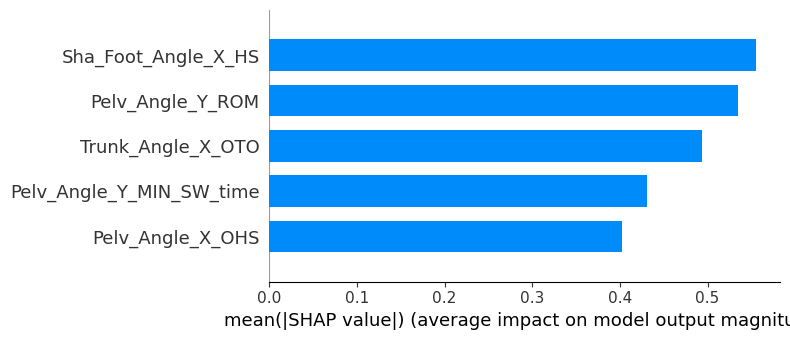

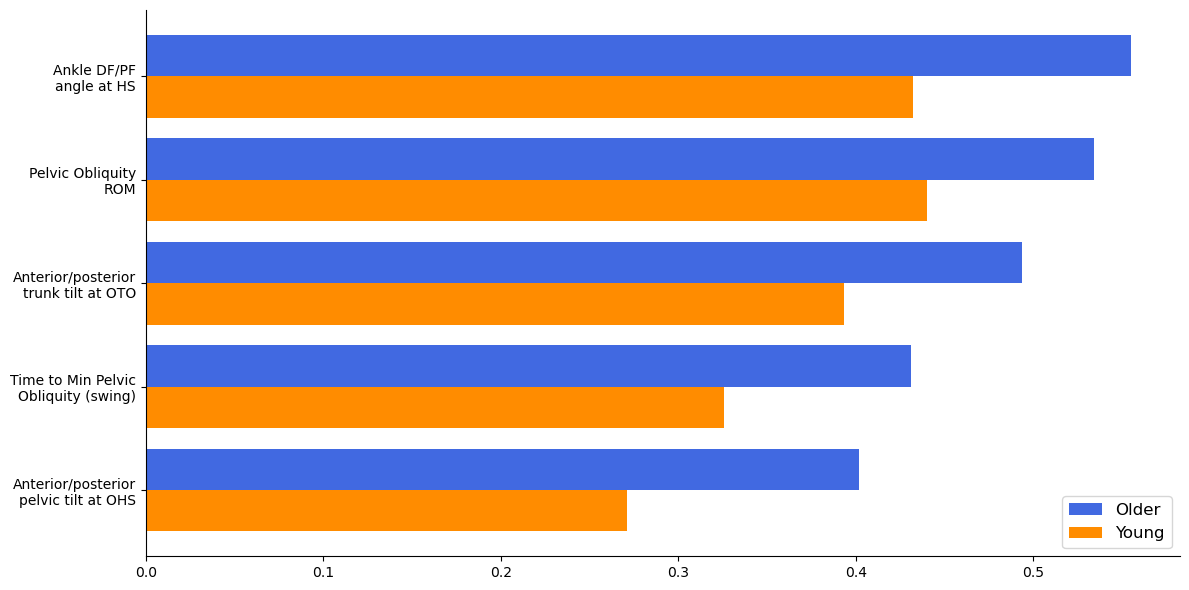

In [8]:
#New features names for plot
features = SHAP_feats
'''
plot_ft_names = ["Shank-Foot PF Angle at\n Heel Strike HS", 
                 "Pelvic Up/Down\n Obliquity ROM", 
                 "Posterior Trunk\n Tilt Angle at OTO", 
                 "Time to Maximum Pelvic\n Down Obliquity Angle in\nSwing", 
                 "Anterior Pelvic Tilt\n Angle at OHS"][::-1]
plot_ft_names = [
    "Ankle PF angle at HS", 
    "Pelvic Obliquity ROM", 
    "Posterior Trunk Tilt\nAngle at OTO", 
    "Time to Min Pelvic\nObliquity (swing)",
    "Anterior Pelvic Tilt\n Angle at OHS"][::-1]
'''

plot_ft_names = [
    "Ankle DF/PF\nangle at HS", 
    "Pelvic Obliquity\nROM", 
    "Anterior/posterior\ntrunk tilt at OTO", 
    "Time to Min Pelvic\nObliquity (swing)",
    "Anterior/posterior\npelvic tilt at OHS"][::-1]

# Generate SHAP summary plot without showing it to extract order
plt.figure()
shap.summary_plot(SHAP_invariant_older[features], feature_names=SHAP_feats, plot_type="bar", max_display=25, show=False)
ax = plt.gca()  # Get current axis from the summary plot

# Extract the feature order from the summary plot
ordered_features = [tick.get_text() for tick in ax.get_yticklabels()]

# Compute mean SHAP values
shap_mean_young = SHAP_invariant_young[features].mean()
shap_mean_older = SHAP_invariant_older[features].mean()

# X locations for the bars
x = np.arange(len(features))  
width = 0.4  # Width of bars

# Generate color gradients
num_features = len(features)
blue_colormap = cm.get_cmap("Blues", num_features + 3)   # 'Blues' for Older
orange_colormap = cm.get_cmap("Oranges", num_features + 3)  # 'Oranges' for Young

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Define colors: Blue for Older, Orange for Young
color_young = "darkorange"
color_older = "royalblue"


# Plot bars with gradient colors in the correct order
# Plot bars for Young and Older groups
bars2 = ax.barh(x + width/2, shap_mean_older[ordered_features], width, label="Older", color=color_older)
bars1 = ax.barh(x - width/2, shap_mean_young[ordered_features], width, label="Young", color=color_young)


# Formatting
ax.set_yticks(x)
ax.set_yticklabels(plot_ft_names)
ax.legend(fontsize=12)
ax.spines['right'].set_visible(False)  # 🔥 Removes the right vertical axis line
ax.spines['top'].set_visible(False)    # 🔥 Removes the top border

# Adjust layout
plt.tight_layout()
plt.show()


In [9]:
models_variant = {}
SHAP_models_values = {}
SHAP_models_features = {}
SHAP_variant_models= {}
SHAP_variant_young = {}
SHAP_variant_older = {}
speed_model = ['Normal', 'Slow', 'Very Slow', 'Fast', 'Very Fast']
feature_counts = 0
for model in variant_EXCEL.sheet_names:
    models_variant[model] = pd.read_excel(variant_EXCEL, sheet_name=model)
    #print("Model load: ", model)
    # Count occurrences
    feature_counts = models_variant[model]['Most Contributing Feat'].value_counts()
    # Get the most frequent feature
    most_frequent_feature = feature_counts.idxmax()
    most_frequent_count = feature_counts.max()  
    # Cols to a list 
    cols = list(models_variant[model].columns)
    first_feature = cols[4]
    last_feature = cols[-3]
    features_model = cols[cols.index(first_feature):cols.index(last_feature)]

    # Features from the model
    if len(features_model) <= 5:
        
        SHAP_models_features[model.split('_')[0]] = features_model
        SHAP_models_values[model.split('_')[0]] = models_variant[model].loc[:, features_model]
        # Save data per class
        SHAP_variant_young[model.split('_')[0]] = models_variant[model][models_variant[model]['Group'] == 0]
        SHAP_variant_older[model.split('_')[0]] = models_variant[model][models_variant[model]['Group'] == 1]

        SHAP_average_MCF = SHAP_models_values[model.split('_')[0]][features_model].mean()
        SHAP_average_MCF_old = SHAP_variant_older[model.split('_')[0]][features_model].mean()
        SHAP_average_MCF_young = SHAP_variant_young[model.split('_')[0]][features_model].mean()
        SHAP_variant_models[model.split('_')[0]] = models_variant[model]

        print("Model load: ", model.split('_')[0])
        print("Most contribuing feature: ", most_frequent_feature)
        print("Cunting of this feature: ", most_frequent_count)
        print("\nSHAP_value Older: \n", SHAP_average_MCF_old)
        print("SHAP_value Young: \n", SHAP_average_MCF_young, '\n')
        #print("SHAP_values:\n",SHAP_average_MCF)
        #print("Features count\n", feature_counts)

Model load:  Normal
Most contribuing feature:  Pelv_Angle_Y_MIN_SW_time
Cunting of this feature:  49

SHAP_value Older: 
 Pelv_Angle_Y_MIN_SW_time    0.675365
Knee_Angle_Y_MIN_SW_time    0.279260
Hip_Angle_X_MAX_SW_time     0.340126
Knee_Angle_X_MAX_SW         0.168706
Hip_Angle_X_MAX_SW          0.241174
dtype: float64
SHAP_value Young: 
 Pelv_Angle_Y_MIN_SW_time    0.806156
Knee_Angle_Y_MIN_SW_time    0.301659
Hip_Angle_X_MAX_SW_time     0.452206
Knee_Angle_X_MAX_SW         0.200464
Hip_Angle_X_MAX_SW          0.267170
dtype: float64 

Model load:  Slow
Most contribuing feature:  Trunk_Angle_X_HS
Cunting of this feature:  25

SHAP_value Older: 
 Cycle_Time                  0.510737
Trunk_Angle_X_HS            0.453095
Hip_Angle_Y_ROM             0.326777
Pelv_Angle_X_HS             0.432192
Pelv_Angle_Y_MIN_SW_time    0.180190
dtype: float64
SHAP_value Young: 
 Cycle_Time                  0.593635
Trunk_Angle_X_HS            0.646230
Hip_Angle_Y_ROM             0.388677
Pelv_Angle_X_

In [20]:
speed_model = ['Very slow', 'Slow', 'Normal', 'Fast', 'Very fast']
for model in speed_model:
    features = SHAP_models_features[model]
    mean_shap_young = SHAP_variant_young[model][features].mean()  # Mean absolute SHAP for Young
    mean_shap_older = SHAP_variant_older[model][features].mean()  # Mean absolute SHAP for Older

    mean_shap_older_sorted = mean_shap_older.sort_values(ascending=False)
    ordered_features = mean_shap_older_sorted.index.tolist()
    print("Model: ", model, '\n', ordered_features)

Model:  Very slow 
 ['Trunk_Angle_X_ROM', 'Sha_Foot_Angle_X_HS', 'Hip_Angle_X_MIN_SW', 'Knee_Angle_Z_TO', 'Pelv_Angle_Y_MAX_SW']
Model:  Slow 
 ['Cycle_Time', 'Trunk_Angle_X_HS', 'Pelv_Angle_X_HS', 'Hip_Angle_Y_ROM', 'Pelv_Angle_Y_MIN_SW_time']
Model:  Normal 
 ['Pelv_Angle_Y_MIN_SW_time', 'Hip_Angle_X_MAX_SW_time', 'Knee_Angle_Y_MIN_SW_time', 'Hip_Angle_X_MAX_SW', 'Knee_Angle_X_MAX_SW']
Model:  Fast 
 ['Hip_Angle_Y_ROM', 'Step_Length', 'Double_Limb_Support_Time', 'Pelv_Angle_Z_ROM', 'Pelv_Angle_Y_MIN_SW_time']
Model:  Very fast 
 ['Pelv_Angle_Y_MIN_SW_time', 'Double_Limb_Support_Time', 'Pelv_Angle_Y_ROM', 'Knee_Angle_Y_MAX_SW_time', 'Trunk_Angle_Z_MAX_SW_time']


In [14]:
file_name = 'Variant Speeds Young and Older\SHAP_top5_models_variant.xlsx'
# Save all sheets to a new Excel file
with pd.ExcelWriter(file_name) as writer:
    for sheet_name, df_SHAP in SHAP_variant_models.items():
        df_SHAP.to_excel(writer, sheet_name=sheet_name, index=False)

In [15]:
matrix_feat = []
for model in SHAP_models_features:
    matrix_feat = matrix_feat + SHAP_models_features[model]
#print("Model: ", model, '\n', SHAP_models_features[model])
print(matrix_feat)
print('Frequency:\n', Counter(matrix_feat))

['Pelv_Angle_Y_MIN_SW_time', 'Knee_Angle_Y_MIN_SW_time', 'Hip_Angle_X_MAX_SW_time', 'Knee_Angle_X_MAX_SW', 'Hip_Angle_X_MAX_SW', 'Cycle_Time', 'Trunk_Angle_X_HS', 'Hip_Angle_Y_ROM', 'Pelv_Angle_X_HS', 'Pelv_Angle_Y_MIN_SW_time', 'Trunk_Angle_X_ROM', 'Hip_Angle_X_MIN_SW', 'Sha_Foot_Angle_X_HS', 'Knee_Angle_Z_TO', 'Pelv_Angle_Y_MAX_SW', 'Hip_Angle_Y_ROM', 'Double_Limb_Support_Time', 'Step_Length', 'Pelv_Angle_Y_MIN_SW_time', 'Pelv_Angle_Z_ROM', 'Pelv_Angle_Y_MIN_SW_time', 'Double_Limb_Support_Time', 'Pelv_Angle_Y_ROM', 'Knee_Angle_Y_MAX_SW_time', 'Trunk_Angle_Z_MAX_SW_time']
Frequency:
 Counter({'Pelv_Angle_Y_MIN_SW_time': 4, 'Hip_Angle_Y_ROM': 2, 'Double_Limb_Support_Time': 2, 'Knee_Angle_Y_MIN_SW_time': 1, 'Hip_Angle_X_MAX_SW_time': 1, 'Knee_Angle_X_MAX_SW': 1, 'Hip_Angle_X_MAX_SW': 1, 'Cycle_Time': 1, 'Trunk_Angle_X_HS': 1, 'Pelv_Angle_X_HS': 1, 'Trunk_Angle_X_ROM': 1, 'Hip_Angle_X_MIN_SW': 1, 'Sha_Foot_Angle_X_HS': 1, 'Knee_Angle_Z_TO': 1, 'Pelv_Angle_Y_MAX_SW': 1, 'Step_Length': 1, 

In [25]:
speed_features = {
    "Normal": [
        "Time to Min Pelvic\nObliquity (swing)",
        "Time to Max Hip Flexion Angle (swing)",
        "Time to Max Knee Valgus Angle (swing)",
        "Max Hip Flexion Angle (swing)",
        "Max Knee Flexion Angle (swing)"
    ],
    "Slow": [
        "Cycle Time",
        "Anterior/posterior Trunk\nTilt Angle at HS",
        "Anterior/posterior\npelvic tilt at HS",
        "Hip Adduction/Abduction ROM",
        "Time to Min Pelvic\nObliquity (swing)"
    ],
    "Very slow": [
        "Trunk Anterior/Posterior\nTilt ROM",
        "Ankle DF/PF angle at HS",
        "Max Hip Flexion Angle (swing)",
        "Knee Ext-Rot Angle at TO",
        "Max Pelvic Downward Obliquity Angle (swing)"
    ],
    "Fast": [
        "Hip Adduction/Abduction\nROM",
        "Step Length",
        "Double Limb Support Time",
        "Pelvic Internal/External Rotation ROM",
        "Time to Min Pelvic\nObliquity (swing)"
    ],
    "Very fast": [
        "Time to Min Pelvic\nObliquity (swing)",
        "Double Limb Support Time",
        "Pelvic Obliquity ROM",
        "Time to Max Knee Varus (swing)",
        "Time to Max Trunk Internal Rotation Angle (swing)"
    ]
}

Normal
Slow
Very slow
Fast
Very fast


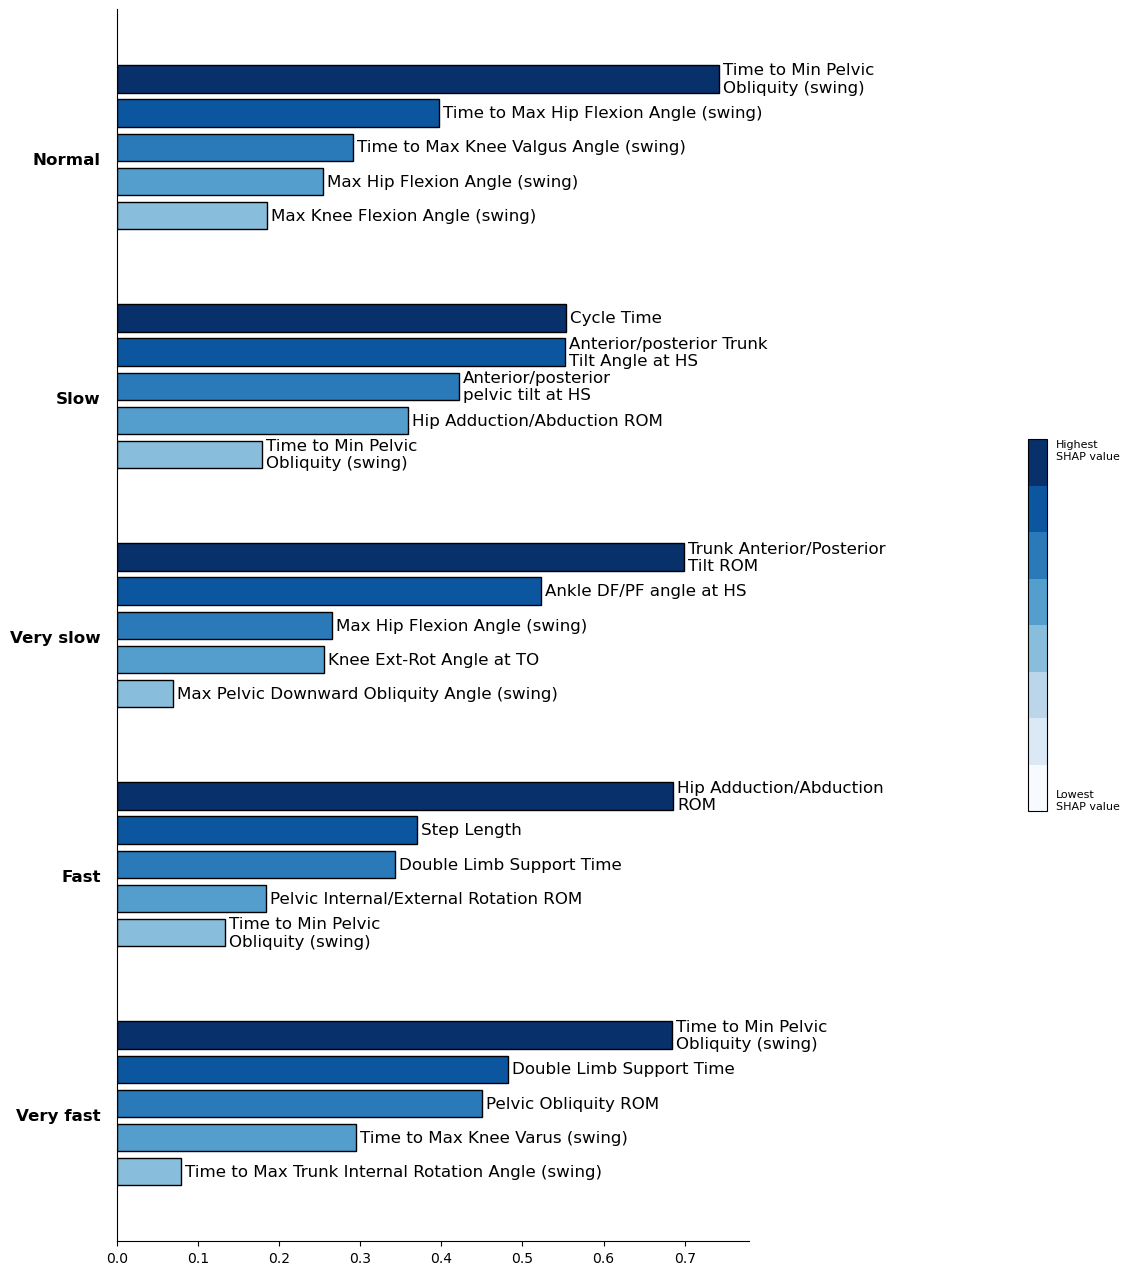

In [26]:
# Reset styles
plt.style.use("default")

# Define the speed categories for the x-axis
speed_model = ['Normal', 'Slow', 'Very slow', 'Fast', 'Very fast']
speed = 0
# Select models to plot
shap_models_keys = list(SHAP_models_values.keys())  # Extract model names
selected_models = shap_models_keys #shap_models_keys[:5]  # Ensure we match the length of `speed_model`

# Initialize figure
fig, ax = plt.subplots(figsize=(12, 16))  # Adjust size

# Generate grayscale or blue gradient color scheme
colormap = cm.get_cmap("Blues", len(selected_models)+3)  # Color scale per model
color = len(selected_models)+2
# Track position for stacking plots
position_offset = 0  # Used to stack different model plots

for idx, model in enumerate(selected_models):
    print(model)
    # Extract SHAP values and features
    model_features = SHAP_models_features[model]
    mean_shap_values = np.abs(SHAP_models_values[model]).mean(axis=0)  # Mean absolute SHAP
    
    # Sort SHAP values for this model
    sorted_indices = np.argsort(mean_shap_values)[::-1]
    model_features = [model_features[i] for i in sorted_indices]
    mean_shap_values = mean_shap_values[sorted_indices]

    speed_features_model = speed_features[speed_model[speed]]
    speed += 1

    # Stack this SHAP plot on the main figure
    for i, (feat, val) in enumerate(zip(speed_features_model, mean_shap_values)):
        # Generate model-specific color (darker for first models)
        model_color = colormap(color)
        color -= 1
        bar = ax.barh(position_offset + i, val, color=model_color, edgecolor="black")
        
        # Add text annotation (Feature Name)
        ax.text(val + 0.005, position_offset + i, feat, fontsize=12, va="center")
    color = len(selected_models)+2
    # Annotate model labels on the left
    ax.text(-0.02, position_offset + len(model_features) / 2, speed_model[idx], fontsize=12, fontweight="bold", ha="right")

    # Increase the position offset for stacking
    position_offset += len(model_features) + 2  # Add spacing

# Remove vertical lines (y-axis) and top/bottom borders
#ax.spines['left'].set_visible(False)   # 🔥 Removes the left vertical axis line
ax.spines['right'].set_visible(False)  # 🔥 Removes the right vertical axis line
ax.spines['top'].set_visible(False)    # 🔥 Removes the top border
#ax.spines['bottom'].set_visible(False) # 🔥 Removes the bottom border

# Format axis
#ax.set_xlabel("Mean |SHAP Value| (Model Impact)", fontsize=12)
ax.set_yticks([])  # Remove y-tick labels to avoid clutter
#ax.set_title("Concatenated SHAP Ranking Across Speed Models", fontsize=14)
ax.invert_yaxis()  # Ensure correct order}

# 🔥 Add colorbar as a gradient label 🔥
cmap = cm.ScalarMappable(cmap=colormap)
cbar = plt.colorbar(cmap, ax=ax, orientation="vertical", fraction=0.02, pad=0.3, shrink=0.8)  # Move right & shrink
# Remove numerical ticks
cbar.set_ticks([])
# Add custom text labels for highest and lowest SHAP values
cbar.ax.text(1.5, 1, "Highest\nSHAP value", fontsize=8, ha="left", va="top")
cbar.ax.text(1.5, 0, "Lowest\nSHAP value", fontsize=8, ha="left", va="bottom")

# Show final stacked SHAP plot
plt.show()

Very fast
Fast
Normal
Slow
Very slow


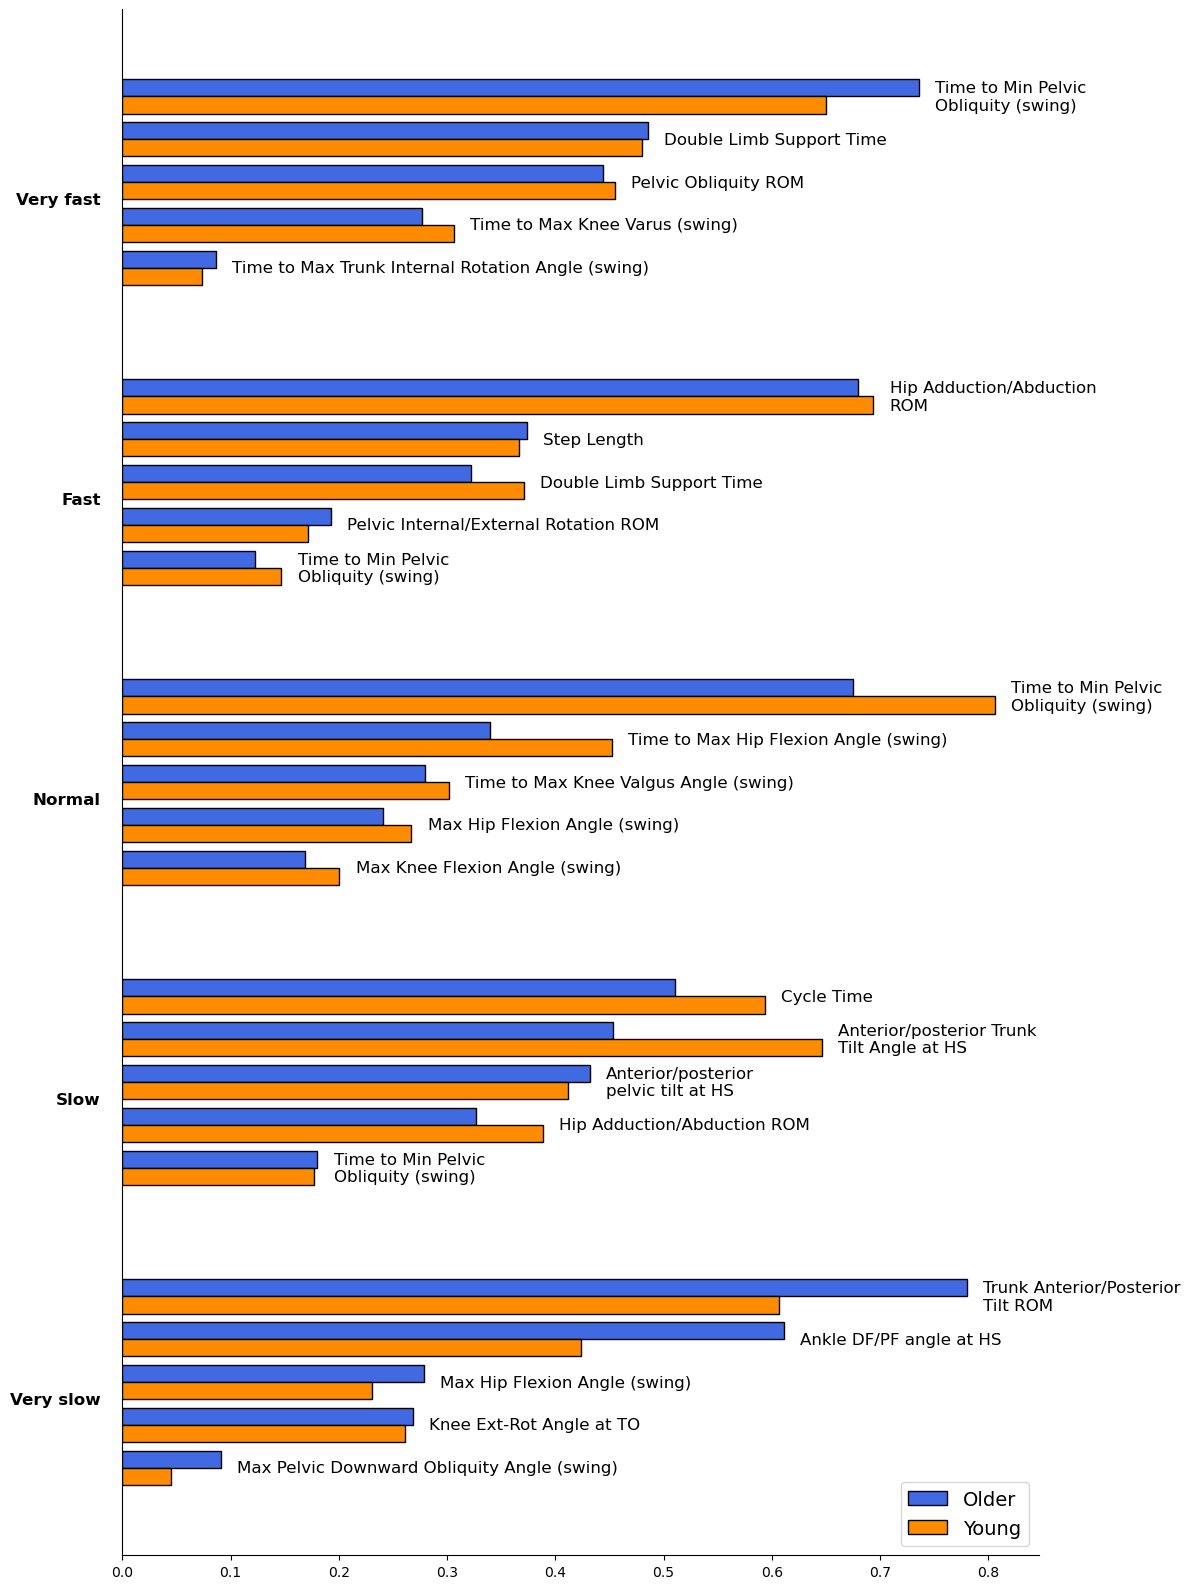

In [27]:
# Define the speed categories for the x-axis
speed_model = ['Very slow', 'Slow', 'Normal', 'Fast', 'Very fast'][::-1]
speed = 0  # Track speed order

# Initialize figure
fig, ax = plt.subplots(figsize=(12, 16))  # Adjust size

# Define colors: Blue for Older, Orange for Young
color_young = "darkorange"
color_older = "royalblue"

# Track position for stacking plots
position_offset = 0  # Used to stack different model plots

for model in speed_model:
    print(model)  # Debugging: See which models are being processed
    
    # Extract SHAP values and features for both groups
    model_features = SHAP_models_features[model]

    mean_shap_young = SHAP_variant_young[model][model_features].mean()  # Mean absolute SHAP for Young
    mean_shap_older = SHAP_variant_older[model][model_features].mean()  # Mean absolute SHAP for Older

    # Order the features from maximum to minimum SHAP value (Older group)
    mean_shap_older_sorted = mean_shap_older.sort_values(ascending=False)
    ordered_features = mean_shap_older_sorted.index.tolist()
    
    # Apply the same order to Young SHAP values
    mean_shap_young_sorted = mean_shap_young.loc[ordered_features]
    plot_ft_names = speed_features[speed_model[speed]]
    #plot_ft_names = ordered_features

    # X locations for bars
    x = np.arange(len(ordered_features))  
    width = 0.4  # Width of bars

    # Plot bars side by side for Young and Older
    bars2 = ax.barh(x - width/2 + position_offset, mean_shap_older_sorted, width, 
                    label="Older" if position_offset == 0 else "", color=color_older, edgecolor="black")
    bars1 = ax.barh(x + width/2 + position_offset, mean_shap_young_sorted, width, 
                    label="Young" if position_offset == 0 else "", color=color_young, edgecolor="black")
    

    # Add text annotations (Feature Names)
    for i, feat in enumerate(ordered_features):
        if mean_shap_young_sorted[feat] > mean_shap_older_sorted[feat]:
            ax.text(mean_shap_young_sorted.iloc[i] + 0.015, position_offset + i, plot_ft_names[i], fontsize=12, va="center")
        else:
            ax.text(mean_shap_older_sorted.iloc[i] + 0.015, position_offset + i, plot_ft_names[i], fontsize=12, va="center")


    # Annotate model labels (Speed Categories) on the left
    ax.text(-0.02, position_offset + len(ordered_features) / 2, speed_model[speed], 
            fontsize=12, fontweight="bold", ha="right")

    # Increase the position offset for stacking
    position_offset += len(ordered_features) + 2  # Add spacing

    # Increment speed index
    speed += 1

# Remove unnecessary axes
ax.spines['right'].set_visible(False)  # 🔥 Removes the right vertical axis line
ax.spines['top'].set_visible(False)    # 🔥 Removes the top border

# Format axis
ax.set_yticks([])
ax.invert_yaxis()  # Ensure correct order

# 🔥 Add legend 🔥
ax.legend(fontsize = 14, loc="lower right")

# Adjust layout for better spacing
plt.tight_layout()

# Show final stacked SHAP plot
plt.show()
